In [39]:
import librosa
import matplotlib.pyplot as plt
import numpy as np 
from IPython.display import Audio 
from scipy.signal import butter, filtfilt
from sklearn.decomposition import FastICA
from scipy.signal import spectrogram


# Exploring the Signal


In [40]:
audio , sample_rate = librosa.load("task5_1.wav" , sr = None)
# Audio(data = audio , rate = sample_rate)

## Time domain 


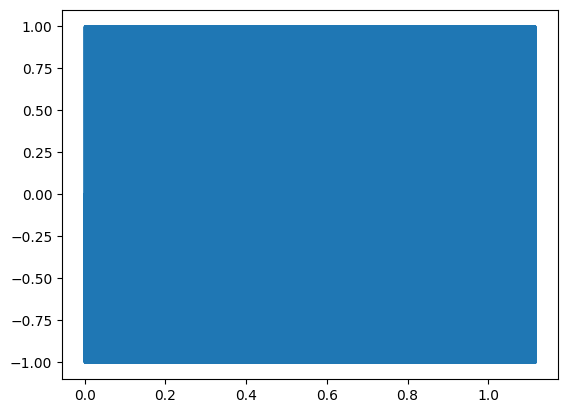

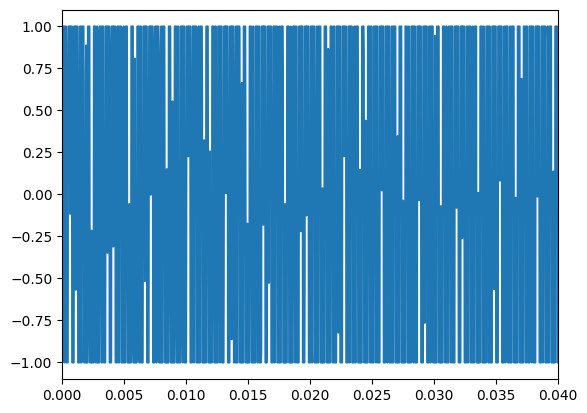

In [41]:
time = np.arange(len(audio)) / sample_rate
plt.plot(time, audio)
plt.show()

"""
okay that gave no information but looking bad ._.
maybe the noise is very large in amplitude relative to the actual sound that it dominates it 
"""

#let's inspect a smaller region from 0 to 0.1 to see without this whole cluster
plt.plot(time, audio)
plt.xlim(0, 0.04)
plt.show()

## Frequency Domain 

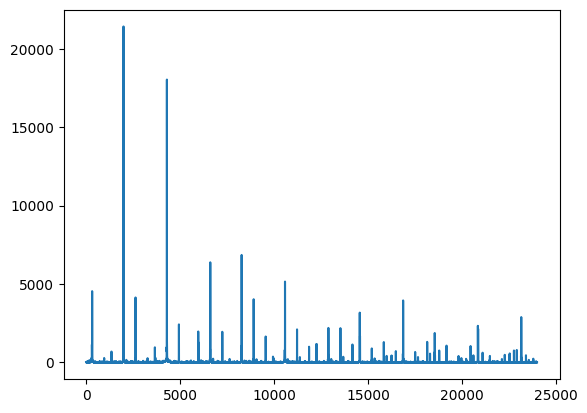

In [42]:
fft = np.fft.rfft(audio)
magnitude = np.abs(fft)

frequencies = np.fft.rfftfreq(len(audio) , 1/sample_rate)

plt.plot(frequencies, magnitude)
plt.show()
#don't think SFT will help since they signal looks the same att all times but will do it later to make sure


# Filtering 

okay let's start with filtering frequencies below 300 and above 4000 that can't be wrong 


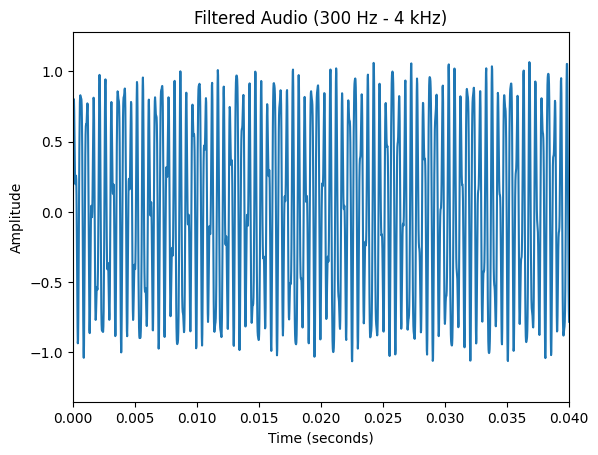

In [43]:
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html
low_cutoff  = 300
high_cutoff = 4000

b, a = butter( N= 4 , Wn= [low_cutoff , high_cutoff] , btype= "bandpass" , fs = sample_rate)
filtered_audio = filtfilt(b, a, audio)

time = np.arange(len(filtered_audio)) / sample_rate
plt.xlim(0,0.04)
plt.plot(time, filtered_audio)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Filtered Audio (300 Hz - 4 kHz)")

plt.show()

Audio(data = filtered_audio , rate = sample_rate) #still same buzz

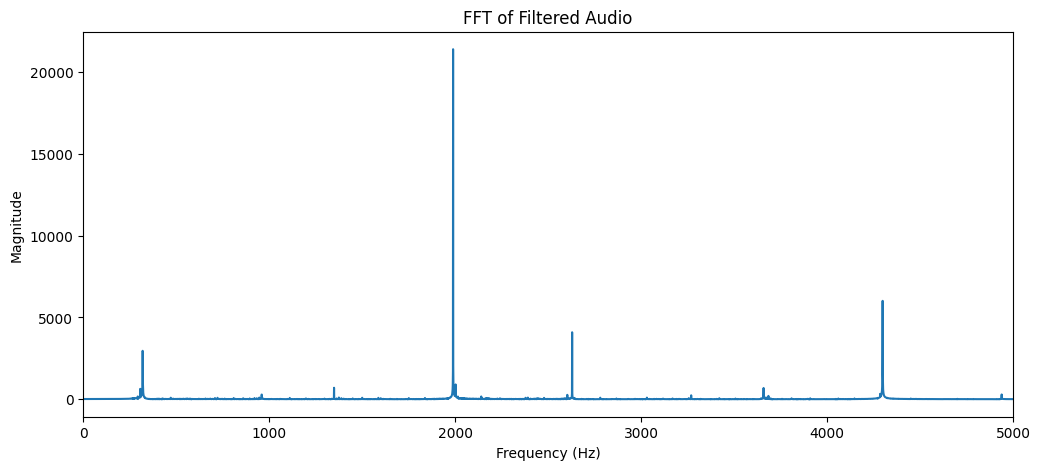

In [44]:
#would be cleaner if i made it as a helper , will do if i used it again

fft = np.fft.rfft(filtered_audio)

magnitude = np.abs(fft)

frequencies = np.fft.rfftfreq(len(filtered_audio), 1 / sample_rate)

plt.figure(figsize=(12, 5))
plt.plot(frequencies, magnitude)

# Show only the frequencies we care about
plt.xlim(0, 5000)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT of Filtered Audio")

plt.show()

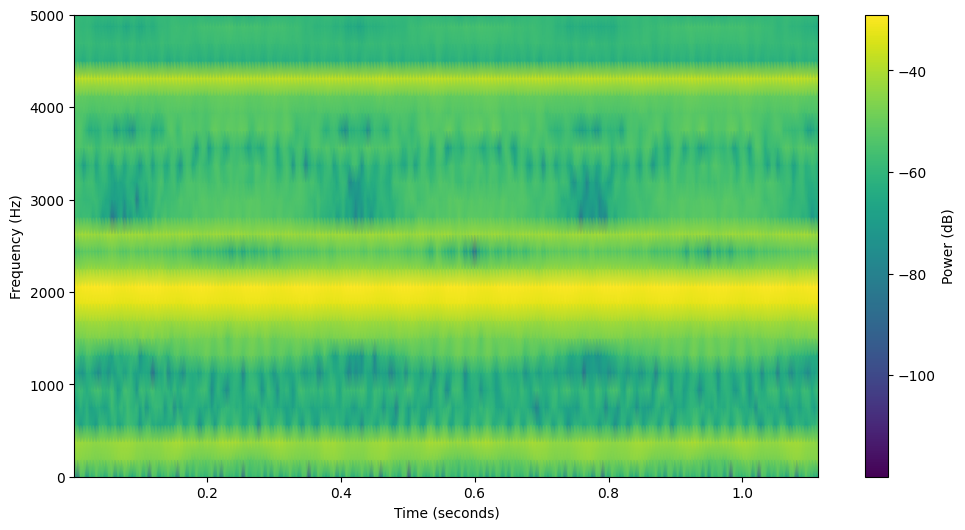

"\nthere are frequencies which have constant magnitude overtime indicating that they're due to a buzzer\n"

In [52]:
frequencies, times, Sxx = spectrogram(
    filtered_audio,
    fs=sample_rate
)

plt.figure(figsize=(12, 6))

plt.pcolormesh(
    times,
    frequencies,
    10 * np.log10(Sxx + 1e-12),
    shading="gouraud"
)

plt.ylim(0, 5000)

plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")

plt.colorbar(label="Power (dB)")

plt.show()

"""
there are frequencies which have constant magnitude overtime indicating that they're due to a buzzer
"""

finding peaks to remove them

In [79]:
from scipy.signal import find_peaks, hilbert, butter, sosfiltfilt

fft = np.fft.rfft(filtered_audio)
freqs = np.fft.rfftfreq(len(filtered_audio), 1/sample_rate)
mag = np.abs(fft)

peaks, _ = find_peaks(mag, height=np.max(mag)*0.003, distance=10)
peak_freqs = freqs[peaks]

def envelope_cv(x, sr, f0, width=15):
    """Coefficient of variation of the amplitude envelope around f0.
    Low = constant tone (buzzer). High = time-varying (speech)."""
    sos = butter(4, [f0-width, f0+width], btype="bandpass", fs=sr, output="sos")
    y = sosfiltfilt(sos, x)
    env = np.abs(hilbert(y))
    n = len(env)
    mid = env[int(0.1*n):int(0.9*n)]   # trim edges, filter transients live there
    return np.std(mid) / (np.mean(mid) + 1e-12)

buzzer_freqs = [f0 for f0 in peak_freqs if f0 >= 100 and envelope_cv(filtered_audio, sample_rate, f0) < 0.15]
print("removing:", buzzer_freqs)

cleaned_audio = filtered_audio.copy()
for f0 in buzzer_freqs:
    sos = butter(N=4, Wn=[f0-15, f0+15], btype="bandstop", fs=sample_rate, output="sos")
    cleaned_audio = sosfiltfilt(sos, cleaned_audio)

removing: [np.float64(307.02097902097904), np.float64(319.5524475524476), np.float64(332.97902097902096), np.float64(959.5524475524476), np.float64(1348.923076923077), np.float64(1972.811188811189), np.float64(1988.923076923077), np.float64(2002.3496503496503), np.float64(2014.881118881119), np.float64(2616.3916083916083), np.float64(2628.923076923077), np.float64(2642.3496503496503), np.float64(3658.2937062937062), np.float64(3684.2517482517483), np.float64(4284.867132867133), np.float64(4298.293706293706), np.float64(4938.293706293706)]


In [80]:
from scipy.signal import butter, sosfiltfilt

cleaned_audio = filtered_audio.copy()
for f0 in peak_freqs:
    if f0 < 100:
        continue
    sos = butter(N=4, Wn=[f0-15, f0+15], btype="bandstop", fs=sample_rate, output="sos")
    cleaned_audio = sosfiltfilt(sos, cleaned_audio)

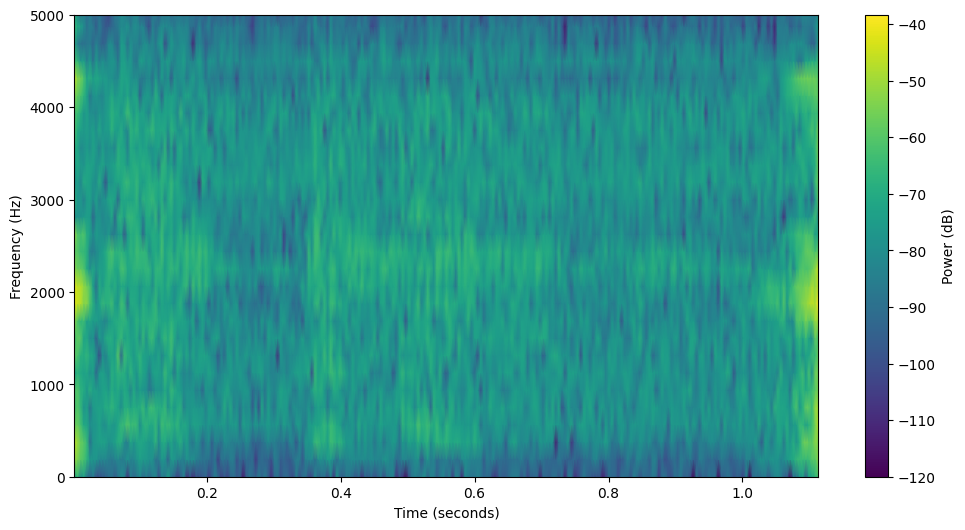

"\nthere are frequencies which have constant magnitude overtime indicating that they're due to a buzzer\n"

In [81]:
frequencies, times, Sxx = spectrogram(
    cleaned_audio,
    fs=sample_rate
)

plt.figure(figsize=(12, 6))

plt.pcolormesh(
    times,
    frequencies,
    10 * np.log10(Sxx + 1e-12),
    shading="gouraud"
)

plt.ylim(0, 5000)

plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")

plt.colorbar(label="Power (dB)")

plt.show()

"""
there are frequencies which have constant magnitude overtime indicating that they're due to a buzzer
"""

In [82]:
Audio(data = cleaned_audio , rate = sample_rate)

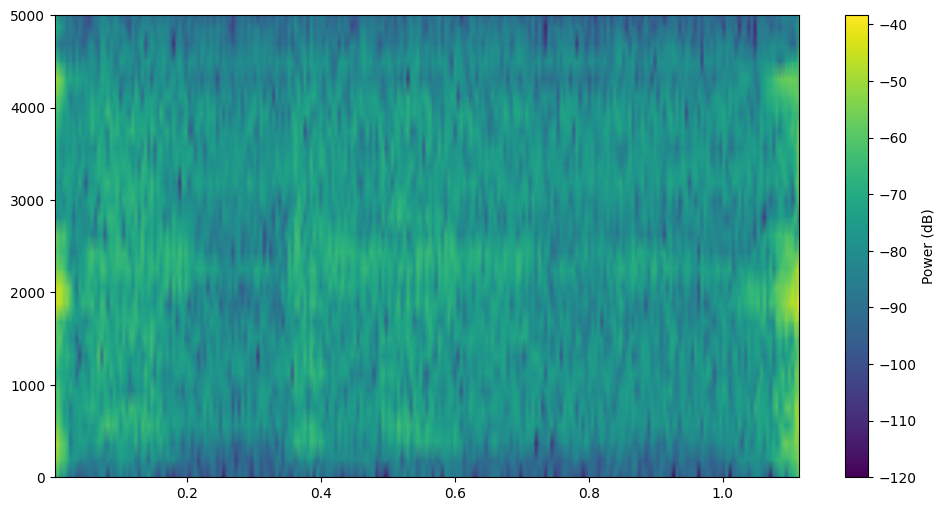

In [83]:
frequencies, times, Sxx = spectrogram(cleaned_audio, fs=sample_rate)
plt.figure(figsize=(12,6))
plt.pcolormesh(times, frequencies, 10*np.log10(Sxx+1e-12), shading="gouraud")
plt.ylim(0, 5000)
plt.colorbar(label="Power (dB)")
plt.show()

## The word is Time-Domain but i'll try to have it in clearer sound 
